In [74]:
import pandas as pd
bsse_data = pd.read_csv("BSSE_by_FF_distance.csv")

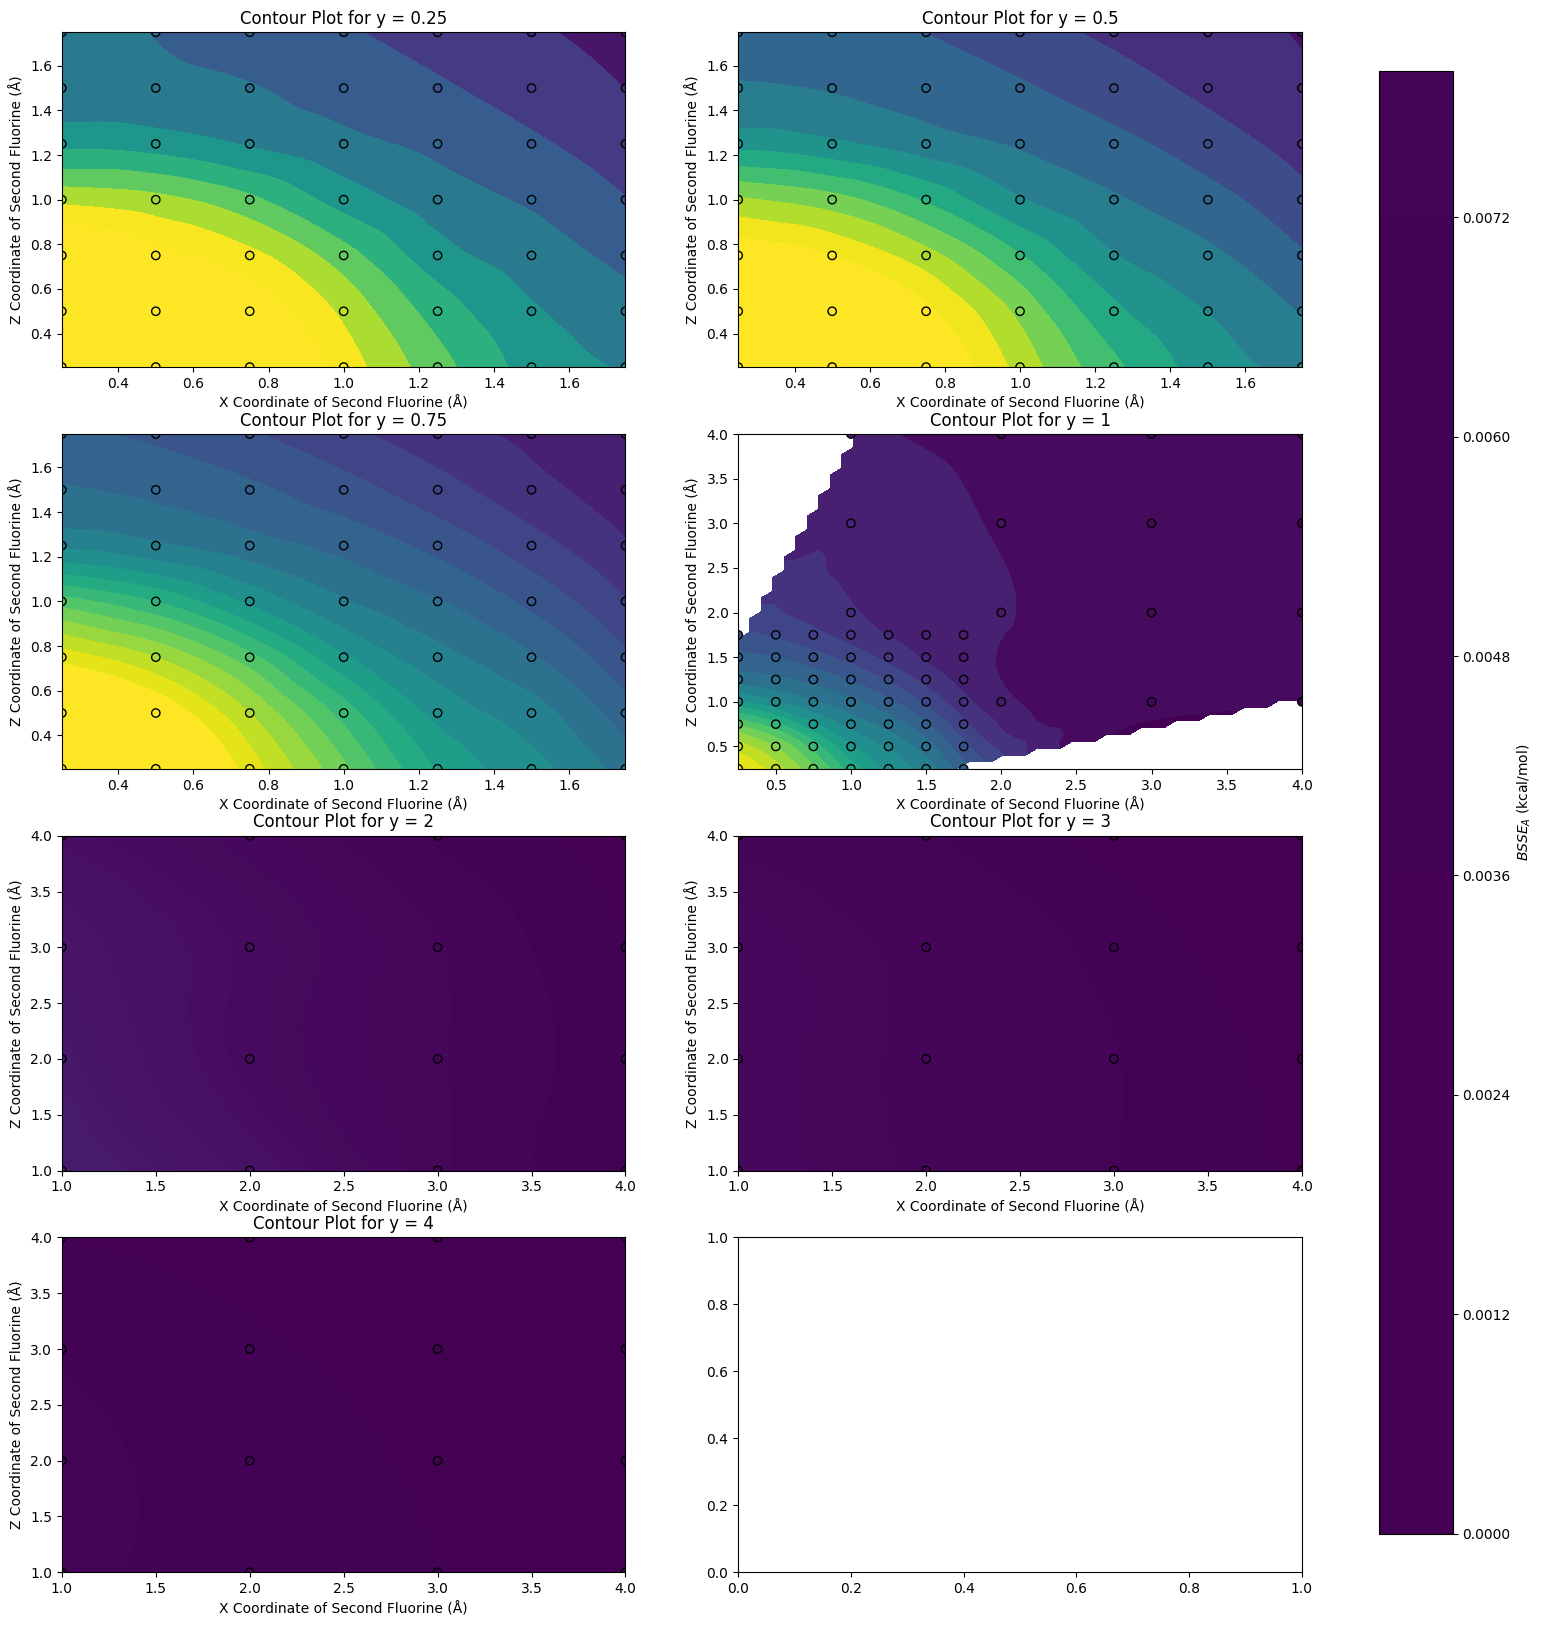

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

fig, axes = plt.subplots(4, 2, figsize=(20, 20))
# remove last row and column
# Store all BSSE values across plots for consistent color scale
all_bsse = []

# First pass: gather global min/max for color normalization
for fixed_y_value in [1, 2, 3, 4]:
    data = bsse_data[bsse_data['y'] == fixed_y_value]
    all_bsse.extend(data['BSSE_A'].values * 627.5096)

vmin = min(all_bsse)
vmax = max(all_bsse)

# Second pass: plotting
for i, fixed_y_value in enumerate([.25, .5, .75, 1, 2, 3, 4]):
    ax = axes[i // 2, i % 2]

    data = bsse_data[bsse_data['y'] == fixed_y_value][['x', 'z', 'BSSE_A']]
    xs = data['x'].values
    zs = data['z'].values
    bsse = data['BSSE_A'].values * 627.5096

    # Grid and interpolation
    xi = np.linspace(min(xs), max(xs), 50)
    zi = np.linspace(min(zs), max(zs), 50)
    Xi, Zi = np.meshgrid(xi, zi)
    bssei = griddata((xs, zs), bsse, (Xi, Zi), method='cubic')

    # Filled contour plot with fixed vmin/vmax
    contour = ax.contourf(Xi, Zi, bssei, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.scatter(xs, zs, c=bsse, cmap='viridis', vmin=vmin, vmax=vmax, edgecolor='k')

    ax.set_title(f'Contour Plot for y = {fixed_y_value}')
    ax.set_xlabel('X Coordinate of Second Fluorine (Å)')
    ax.set_ylabel('Z Coordinate of Second Fluorine (Å)')

# Shared colorbar
fig.colorbar(contour, ax=axes.ravel(), label='$BSSE_{A}$ (kcal/mol)', shrink=0.95)

plt.show()


/var/folders/v1/k9l8hql13n1gcrjl_yh_gs5m0000gn/T/ipykernel_10659/705835394.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


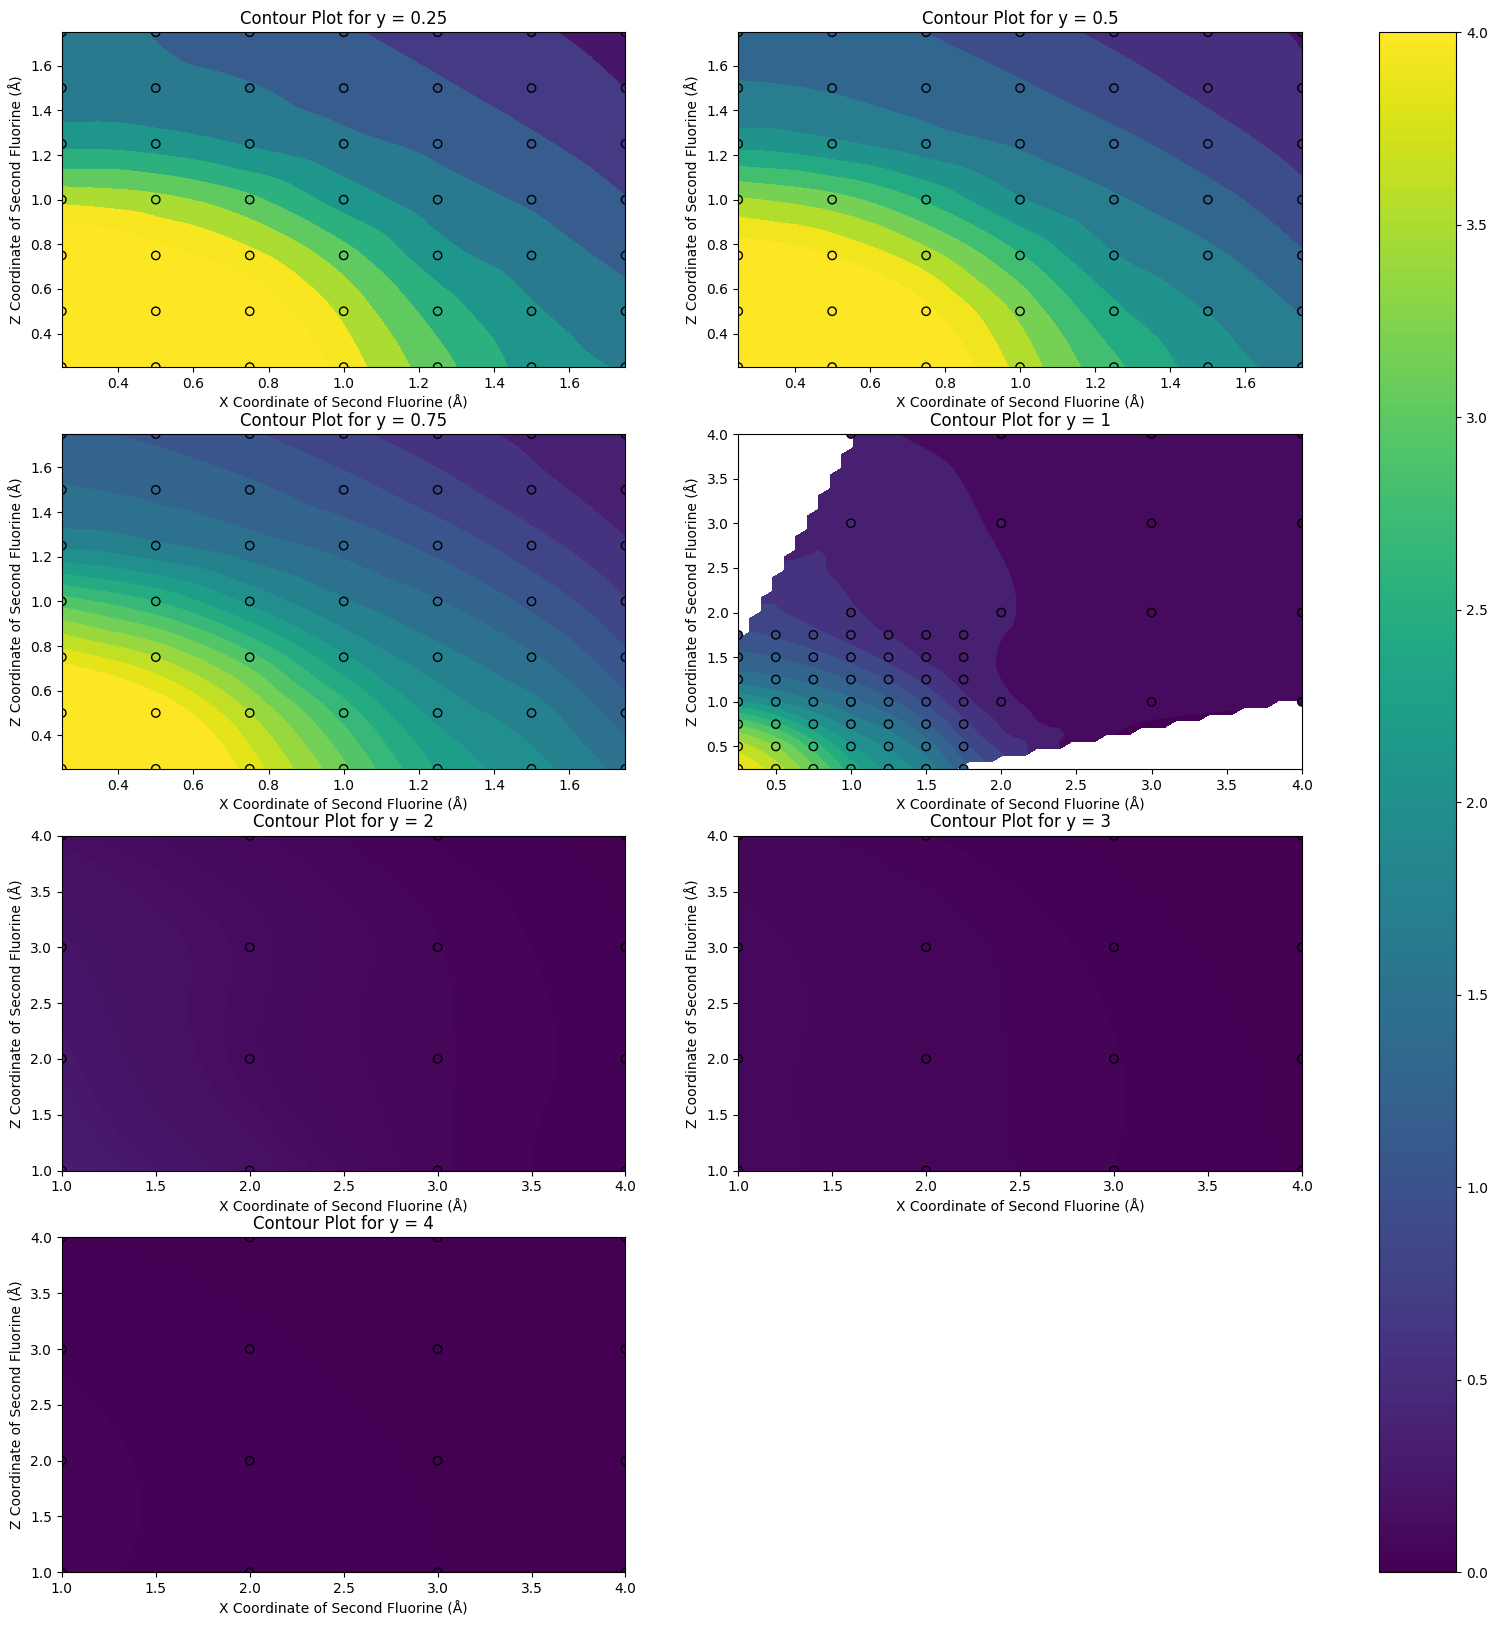

In [97]:
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
cmap = cm.get_cmap('viridis')
normalizer = Normalize(0, 4)
im = cm.ScalarMappable(norm=normalizer)
fig.delaxes(axes[3][1])
for i, fixed_y_value in enumerate([.25, .5, .75, 1, 2, 3, 4]):
    ax = axes[i // 2, i % 2]

    data = bsse_data[bsse_data['y'] == fixed_y_value][['x', 'z', 'BSSE_A']]
    xs = data['x'].values
    zs = data['z'].values
    bsse = data['BSSE_A'].values * 627.5096

    # Grid and interpolation
    xi = np.linspace(min(xs), max(xs), 50)
    zi = np.linspace(min(zs), max(zs), 50)
    Xi, Zi = np.meshgrid(xi, zi)
    bssei = griddata((xs, zs), bsse, (Xi, Zi), method='cubic')

    # Filled contour plot with fixed vmin/vmax
    contour = ax.contourf(Xi, Zi, bssei, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.scatter(xs, zs, c=bsse, cmap='viridis', vmin=vmin, vmax=vmax, edgecolor='k')

    ax.set_title(f'Contour Plot for y = {fixed_y_value}')
    ax.set_xlabel('X Coordinate of Second Fluorine (Å)')
    ax.set_ylabel('Z Coordinate of Second Fluorine (Å)')
fig.colorbar(im, ax=axes.ravel().tolist())
plt.show()